# Hierarchical Risk Parity (HRP) — Research Method Replication

## Project Overview

This project implements the **Hierarchical Risk Parity (HRP)** portfolio construction method developed by Marcos López de Prado and reproduces the core numerical example supplied in the reference material. The objective is to translate the research methodology into a transparent Python workflow while preserving the financial and mathematical reasoning behind each stage.

HRP addresses a central weakness of classical quadratic portfolio optimization: portfolio weights can become highly unstable when the covariance matrix is noisy, ill-conditioned, or singular. Instead of inverting the covariance matrix, HRP uses **hierarchical clustering** to organize assets into a tree and then allocates capital recursively according to cluster risk.

The implementation follows the three stages described in the reference methodology:

1. **Tree clustering** — transform correlations into distances and infer a hierarchical dependency structure.
2. **Quasi-diagonalization** — reorder assets so that similar investments become adjacent.
3. **Recursive bisection** — allocate capital top-down, giving more weight to lower-variance branches.

The notebook first develops each component on small controlled examples and then combines them to reproduce the 10-series synthetic experiment.

> **Scope.** This implementation reproduces the HRP construction logic and the numerical allocation example. It does **not** implement the Critical Line Algorithm (CLA) benchmark or the 10,000-run out-of-sample Monte Carlo experiment presented later in the reference chapter. Any claims about those experiments therefore belong to the source material, not to the empirical results of this notebook.

## Methodological Motivation

Traditional minimum-variance optimization depends on the inverse covariance matrix. When assets are strongly correlated, small estimation errors can create large changes in that inverse and therefore large changes in portfolio weights. López de Prado refers to this tension as **Markowitz's curse**: correlation increases the need for diversification while simultaneously making covariance-based optimization less numerically stable.

HRP replaces the fully connected dependency structure implicit in a covariance matrix with a **hierarchical tree**. Economically, this introduces a structured notion of substitution: closely related assets compete for capital within nearby branches before allocations are propagated across more distant groups. The result is an allocation procedure that uses covariance information without requiring matrix inversion.

---

## 1. Correlation-Based Distance

The first step converts pairwise correlations into a metric distance:

$$
d_{ij} = \sqrt{\frac{1-\rho_{ij}}{2}}.
$$

Here, $\rho_{ij}$ is the correlation between assets $i$ and $j$. The transformation maps correlation into the interval $[0,1]$: perfectly positively correlated series have distance $0$, uncorrelated series have distance $\sqrt{1/2}$, and perfectly negatively correlated series have distance $1$.

This is more than a rescaling of correlation. It creates a proper metric representation that can be used by clustering algorithms. The following three-variable example reproduces the first numerical transformation in the reference methodology.

In [3]:
import numpy as np
import pandas as pd

corr_matrix = pd.DataFrame(
    [
        [1.0, 0.7, 0.2],
        [0.7, 1.0, -0.2],
        [0.2, -0.2, 1.0],
    ],
    index=["X1", "X2", "X3"],
    columns=["X1", "X2", "X3"],
)

distance_matrix = np.sqrt((1 - corr_matrix) / 2)

distance_matrix.round(4)

,X1,X2,X3
X1,0.0000,0.3873,0.6325
X2,0.3873,0.0000,0.7746
X3,0.6325,0.7746,0.0000


The resulting matrix preserves the dependence information while expressing it geometrically. For example, $X_1$ and $X_2$ are the closest pair because their correlation is the highest.

---

## 2. Distance Between Dependency Profiles

HRP does not cluster assets using only one pairwise correlation at a time. For each asset, the corresponding column of the distance matrix represents its **distance profile relative to the entire investment universe**.

The second distance is therefore:

$$
\tilde d_{ij}
=
\sqrt{
\sum_{n=1}^{N}
\left(d_{ni}-d_{nj}\right)^2
}.
$$

Two assets are close under $\tilde d_{ij}$ when they have similar relationships with all other assets. This introduces a multivariate notion of similarity: the clustering step compares dependency profiles, not only isolated pairwise correlations.

In [4]:
labels = distance_matrix.columns
n_assets = len(labels)

distance_of_distances = np.zeros((n_assets, n_assets))

for i in range(n_assets):
    for j in range(n_assets):

        profile_i = distance_matrix.iloc[:, i].values
        profile_j = distance_matrix.iloc[:, j].values

        difference = profile_i - profile_j

        distance_of_distances[i, j] = np.sqrt(
            np.sum(difference ** 2)
        )

distance_of_distances = pd.DataFrame(
    distance_of_distances,
    index=labels,
    columns=labels
)

distance_of_distances.round(4)

,X1,X2,X3
X1,0.0000,0.5659,0.9747
X2,0.5659,0.0000,1.1225
X3,0.9747,1.1225,0.0000


For the three-series example, the smallest profile distance remains between $X_1$ and $X_2$, so they are the natural first cluster.

---

## 3. Hierarchical Tree Clustering

The condensed profile-distance vector is passed to SciPy's hierarchical clustering routine using **single linkage**. Under single linkage, the distance between two clusters is determined by the closest pair of observations across the clusters.

Conceptually, this stage converts the complete dependency structure into a tree. The linkage matrix records which nodes are merged, the distance at which each merge occurs, and the number of original observations contained in each new cluster.

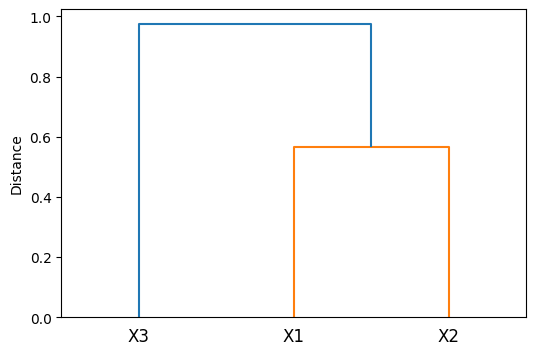

In [5]:
from scipy.spatial.distance import pdist
import scipy.cluster.hierarchy as sch 

# Euclidean distances between the distance profiles 
profile_distances = pdist(
    distance_matrix.values,
    metric = "euclidean"
)

linkage_matrix = sch.linkage(
    profile_distances,
    method = "single"
)

linkage_matrix

import matplotlib.pyplot as plt

plt.figure(figsize = (6,4))

sch.dendrogram(
    linkage_matrix,
    labels = distance_matrix.columns.tolist()
)

plt.ylabel("Distance")
plt.show()

The dendrogram is the visual representation of this hierarchy. Merge heights measure the profile distance at which branches become connected; lower merges correspond to stronger similarity in the correlation structure.

---

## 4. Quasi-Diagonalization

Hierarchical clustering identifies a tree, but the allocation stage needs an ordered list of the original assets. **Quasi-diagonalization** recursively expands the final cluster until only leaf nodes remain.

The purpose is not to transform the covariance matrix into a new factor basis. Instead, it **reorders the original assets** so that strongly related investments are placed next to one another. If the covariance or correlation matrix is rearranged according to this ordering, large dependence values tend to appear in blocks close to the diagonal.

In [6]:
def quasi_diagonalize(linkage_matrix):
    """
    Return the order of the original assets implied by the hierarchical tree
    """
    linkage_matrix = linkage_matrix.astype(int)

    # Number of original assets
    n_assets = int(linkage_matrix[-1, 3])

    # Start from the two children of the root cluster 
    sorted_indices = [
    int(linkage_matrix[-1,0]),
    int(linkage_matrix[-1,1])
    ]

    # Expand clusters until only original asstes remain
    while any(idx >= n_assets for idx in sorted_indices):

        expanded_indices = []

        for idx in sorted_indices: 

            if idx < n_assets:
                # Original asset : keep it
                expanded_indices.append(idx)
            else: 
                cluster_row = idx - n_assets

                left_child = int(linkage_matrix[cluster_row, 0])
                right_child = int(linkage_matrix[cluster_row, 1])

                expanded_indices.extend(
                    [left_child, right_child]
                )
        sorted_indices = expanded_indices 

    return sorted_indices 
            

# Eseguiamo la funzione 
sorted_indices = quasi_diagonalize(linkage_matrix)

In [7]:
sorted_indices = quasi_diagonalize(
    linkage_matrix
)

sorted_assets = [
    distance_matrix.columns[i]
    for i in sorted_indices
]

print("Sorted indices:", sorted_indices)
print("Sorted assets:", sorted_assets)

Sorted indices: [2, 0, 1]
Sorted assets: ['X3', 'X1', 'X2']


For this three-variable example, the recovered order is `X3, X1, X2`. The ordering preserves the tree structure and prepares the portfolio for contiguous recursive splits.

---

## 5. Inverse-Variance Allocation

Before implementing recursive bisection, the notebook isolates the inverse-variance portfolio (IVP), which is the local risk-allocation rule used inside HRP.

For a diagonal covariance matrix, the minimum-variance fully invested portfolio assigns weights proportional to inverse variance:

$$
w_i
=
\frac{\sigma_i^{-2}}
{\sum_{j=1}^{N}\sigma_j^{-2}}.
$$

The intuition is direct: an asset with four times the variance of another asset receives one quarter of its unnormalized risk weight. This rule is exact for a diagonal covariance matrix and becomes the building block used to summarize the risk of each HRP cluster.

In [8]:
cov_matrix = pd.DataFrame(
    [
        [1.0, 0.0, 0.0],
        [0.0, 2.0, 0.0],
        [0.0, 0.0, 4.0],
    ],
    index = ["X1", "X2", "X3"],
    columns = ["X1", "X2", "X3"],
)

cov_matrix

,X1,X2,X3
X1,1.0,0.0,0.0
X2,0.0,2.0,0.0
X3,0.0,0.0,4.0


In [9]:
def inverse_variance_weights(cov_matrix):
    """
    Compute inverse-variance portfolio weights.
    """

    variances = np.diag(cov_matrix)

    inverse_variances = 1.0 / variances

    weights = inverse_variances / inverse_variances.sum()

    return weights

# Eseguiamo 
ivp_weights = inverse_variance_weights(
    cov_matrix.values
)

ivp_weights

array([0.57142857, 0.28571429, 0.14285714])

The example returns approximately $(0.5714, 0.2857, 0.1429)$ for variances $(1,2,4)$, illustrating the inverse relationship between variance and capital allocation.

---

## 6. Measuring Cluster Risk

HRP needs a scalar measure of risk for every branch that appears during recursive bisection. For a cluster $C$, the code extracts the cluster covariance matrix $\Sigma_C$, computes local inverse-variance weights $w_C$, and evaluates the quadratic form:

$$
V_C = w_C^\top \Sigma_C w_C.
$$

This quantity is the variance of the cluster when its constituents are combined using inverse-variance weights. It compresses the risk of a multi-asset branch into a single number that can be compared with the risk of its sibling branch.

In [10]:
def cluster_variance(cov_matrix, cluster_indices):
    """
    Compute the variance of a cluster using inverse-variance weights.
    """

    cluster_cov = cov_matrix[
        np.ix_(cluster_indices, cluster_indices)
    ]

    cluster_weights = inverse_variance_weights(
        cluster_cov
    )

    variance = (
        cluster_weights.T
        @ cluster_cov
        @ cluster_weights
    )

    return float(variance)

In [11]:
larger_cov = np.array(
    [
        [1.0, 0.2, 0.1],
        [0.2, 4.0, 0.3],
        [0.1, 0.3, 9.0],
    ]
)

cluster_indices = [0,1]

cluster_variance(larger_cov, cluster_indices)

0.8640000000000002

This distinction matters: HRP does not compare clusters only through the individual variances of their members. The quadratic form also incorporates the covariance terms within the cluster.

---

## 7. Recursive Bisection

The final allocation stage starts with unit weight assigned to every asset in the quasi-diagonal order and repeatedly bisects each non-singleton cluster into two contiguous subclusters.

For left and right cluster variances $V_L$ and $V_R$, the capital share assigned to the left branch is:

$$
\alpha
=
1-\frac{V_L}{V_L+V_R}
=
\frac{V_R}{V_L+V_R},
$$

while the right branch receives $1-\alpha$. Therefore, the **lower-risk branch receives the larger allocation**. Because each split only redistributes the weight inherited from its parent, the final portfolio remains fully invested and non-negative.

In [12]:
test_cov = np.diag(
    [1.0, 1.0, 1.0, 3.0]
)

sorted_indices = [0, 1, 2, 3]

In [13]:
def recursive_bisection(cov_matrix, sorted_indices):
    """
    Compute HRP weights through recursive bisection.
    """

    # Start with unit weights for all assets
    weights = pd.Series(
        1.0,
        index=sorted_indices
    )

    # Initially all assets belong to one cluster
    clusters = [list(sorted_indices)]

    while len(clusters) > 0:

        new_clusters = []

        # Bisect every cluster that contains more than one asset
        for cluster in clusters:

            if len(cluster) > 1:

                split = len(cluster) // 2

                left_cluster = cluster[:split]
                right_cluster = cluster[split:]

                new_clusters.append(left_cluster)
                new_clusters.append(right_cluster)

        clusters = new_clusters

        # Process the newly created clusters in pairs
        for i in range(0, len(clusters), 2):

            left_cluster = clusters[i]
            right_cluster = clusters[i + 1]

            left_variance = cluster_variance(
                cov_matrix,
                left_cluster
            )

            right_variance = cluster_variance(
                cov_matrix,
                right_cluster
            )

            # Allocate more capital to the lower-risk cluster
            alpha = (
                1.0
                - left_variance
                / (left_variance + right_variance)
            )

            weights.loc[left_cluster] *= alpha

            weights.loc[right_cluster] *= (
                1.0 - alpha
            )

    return weights

The recursion continues until every branch contains a single asset. This is the key portfolio-construction mechanism: risk is allocated through the hierarchy rather than through a global covariance-matrix inversion.

---

## 8. End-to-End HRP Allocation

The following function combines the complete pipeline:

**correlation matrix → correlation distance → profile distance → hierarchical clustering → quasi-diagonalization → recursive bisection → portfolio weights**

In [17]:
def hrp_allocation(cov_matrix, corr_matrix):

    # Step 1: convert correlations into distances
    distance_matrix = np.sqrt(
        (1.0 - corr_matrix) / 2.0)

    # Step 2: Compute Euclidean Distances between distance profiles
    profile_distances = pdist(
        distance_matrix.values,
        metric = "euclidean"
    )

    # Step 3: hierarchical clustering
    linkage_matrix = sch.linkage(
        profile_distances,
        method = "single"
    )

    # step 4
    sorted_indices = quasi_diagonalize(linkage_matrix)

    # step 5: recursive bisection
    weights = recursive_bisection(
        cov_matrix.values,
        sorted_indices
    )

    # Convert integer positions back to asset names
    weights.index = cov_matrix.columns[weights.index]

    # Restore the original asset order
    weights = weights.reindex(cov_matrix.columns)

    return weights
    

### Controlled Three-Asset Test

The next test uses the same three-asset correlation structure introduced earlier. The covariance matrix is intentionally set equal to the correlation matrix, which is valid here as a controlled **unit-variance** example. In general, covariance and correlation matrices are not interchangeable.

In [18]:
corr_matrix = pd.DataFrame(
    [
        [1.0, 0.7, 0.2],
        [0.7, 1.0, -0.2],
        [0.2, -0.2, 1.0],
    ],
    index=["X1", "X2", "X3"],
    columns=["X1", "X2", "X3"],
)

cov_matrix = corr_matrix.copy()

In [19]:
hrp_weights = hrp_allocation(
    cov_matrix,
    corr_matrix
)

hrp_weights

X1    0.270270
X2    0.270270
X3    0.459459
dtype: float64

The resulting HRP weights are approximately:

| Asset | HRP Weight |
|---|---:|
| X1 | 27.03% |
| X2 | 27.03% |
| X3 | 45.95% |

The allocation reflects both the hierarchical ordering and the aggregated variance of each branch. Because $X_1$ and $X_2$ are strongly related, they are treated as a nearby cluster and split the capital assigned to that branch.

---

# Reproducing the Numerical Example

## 9. Synthetic Data Generation

The reference numerical experiment uses 10 series: five independent Gaussian base series and five noisy copies of selected base series. This construction creates a known correlation structure, allowing the clustering algorithm to be evaluated against relationships that are known by design.

The implementation fixes the source mapping to:

- series 6 as a noisy copy of series 3;
- series 7 as a noisy copy of series 1;
- series 8 as a noisy copy of series 5;
- series 9 as a noisy copy of series 2;
- series 10 as another noisy copy of series 2.

With 10,000 observations and noise standard deviation $0.25$, the generated data reproduce the dependency pattern used in the reference example.

In [23]:
def generate_data(
    n_obs = 10000,
    size0 = 5,
    size1 = 5,
    sigma1 = 0.25,
    seed = 12345
):


    np.random.seed(seed)

    # 1. I'm going to generate the five independent Gaussian series
    x_base = np.random.normal(
        loc = 0.0,
        scale = 1.0,
        size = (n_obs, size0)
    )

    source_cols = [2, 0, 4, 1, 1]

    assert len(source_cols) == size1

    # 2. I'm going to add independent noise to the selected original series
    noise = np.random.normal(
        loc = 0.0,
        scale = sigma1,
        size = (n_obs, size1)
    )

    x_correlated = x_base[:, source_cols] + noise

    # 3. I'm going to combine the original and correlated series 
    x = np.concatenate(
        [x_base, x_correlated],
        axis = 1
    )

    data = pd.DataFrame(
        x,
        columns = range(1, x.shape[1] + 1)
    )

    return data, source_cols

    

In [24]:
data, source_cols = generate_data()

data.shape

(10000, 10)

In [25]:
data

,1,2,3,4,5,6,7,8,9,10
0,-0.204708,0.478943,-0.519439,-0.555730,1.965781,-0.713604,0.243765,2.150762,0.347517,0.507267
1,1.393406,0.092908,0.281746,0.769023,1.246435,0.289047,1.383806,1.387060,-0.203323,0.495478
2,1.007189,-1.296221,0.274992,0.228913,1.352917,-0.272708,1.042476,1.007276,-1.367614,-1.619432
3,0.886429,-2.001637,-0.371843,1.669025,-0.438570,-0.451449,0.911014,-0.790299,-1.568576,-2.197302
4,-0.539741,0.476985,3.248944,-1.021228,-0.577087,3.126706,-0.574899,-0.458569,0.495949,0.257233
...,...,...,...,...,...,...,...,...,...,...
9995,3.024868,1.608706,0.222607,-1.002391,-1.052142,0.145550,2.856461,-0.898981,1.416062,1.754102
9996,0.009564,1.134083,-0.333766,-1.091950,-0.915227,-0.587262,0.366653,-1.495926,0.875206,0.887250
9997,-1.270282,0.809146,-0.450842,0.471795,1.894011,0.001885,-1.309590,1.788093,0.932708,0.924528
9998,-0.688909,0.088575,-0.563593,-0.411351,0.651575,-0.668777,-0.961016,0.494739,-0.016414,-0.162293


Displaying the generated data is simply a structural inspection step; the quantitative analysis begins with the estimated covariance and correlation matrices.

---

## 10. Estimating the Dependence Structure

The covariance matrix supplies the risk information required by recursive bisection, while the correlation matrix supplies the normalized dependency structure used for clustering.

In [28]:
corr_matrix = data.corr()
cov_matrix = data.cov()

corr_matrix.round(4)

,1,2,3,4,5,6,7,8,9,10
1,1.0000,-0.0030,0.0100,-0.0107,-0.0050,0.0085,0.9701,-0.0013,-0.0012,-0.0090
2,-0.0030,1.0000,0.0086,0.0073,-0.0094,0.0126,-0.0091,-0.0147,0.9701,0.9713
3,0.0100,0.0086,1.0000,-0.0006,0.0018,0.9705,0.0062,0.0019,0.0124,0.0077
4,-0.0107,0.0073,-0.0006,1.0000,0.0057,0.0009,-0.0115,0.0004,0.0121,0.0092
5,-0.0050,-0.0094,0.0018,0.0057,1.0000,0.0054,-0.0093,0.9700,-0.0059,-0.0076
6,0.0085,0.0126,0.9705,0.0009,0.0054,1.0000,0.0042,0.0054,0.0161,0.0108
7,0.9701,-0.0091,0.0062,-0.0115,-0.0093,0.0042,1.0000,-0.0063,-0.0076,-0.0152
8,-0.0013,-0.0147,0.0019,0.0004,0.9700,0.0054,-0.0063,1.0000,-0.0111,-0.0128
9,-0.0012,0.9701,0.0124,0.0121,-0.0059,0.0161,-0.0076,-0.0111,1.0000,0.9427
10,-0.0090,0.9713,0.0077,0.0092,-0.0076,0.0108,-0.0152,-0.0128,0.9427,1.0000


The estimated correlations recover the intended synthetic design: each noisy copy is strongly correlated with its source series, while most unrelated base series remain close to zero correlation.

### Original Correlation Matrix

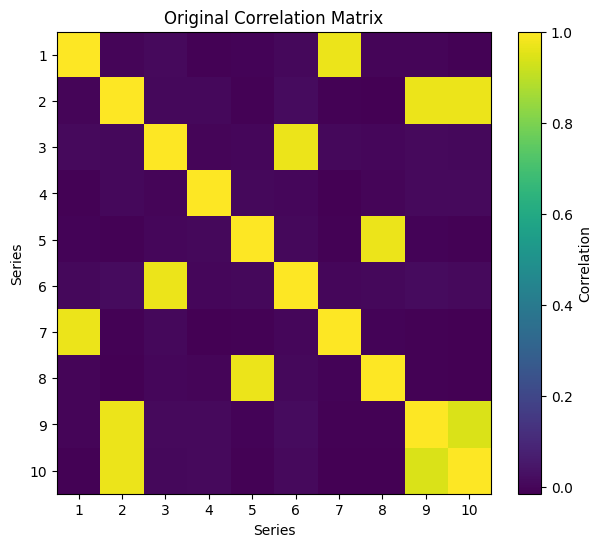

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.imshow(
    corr_matrix.values,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index
)

plt.xlabel("Series")
plt.ylabel("Series")
plt.title("Original Correlation Matrix")

plt.show()

The heatmap provides a visual diagnostic before clustering. At this stage, related assets can be far apart in the original ordering, so the block structure is not yet organized along the diagonal.

---

## 11. Correlation Distance and Profile Distance

The full 10-series example applies the same two-stage distance construction developed earlier.

First, pairwise correlations are converted to the metric distance $d_{ij}$. Then Euclidean distances are computed between the columns of that distance matrix, producing the condensed profile-distance vector required by SciPy's linkage algorithm.

In [30]:
distance_matrix = np.sqrt(
    (1.0 - corr_matrix) / 2.0
)

In [31]:
profile_distances = pdist(
    distance_matrix.values, 
    metric = "euclidean"
)

This explicit use of profile distances mirrors the theoretical description of the method: clustering depends on how each asset relates to the **entire** correlation structure.

---

## 12. Single-Linkage Hierarchical Clustering

The profile distances are clustered using the single-linkage criterion.

In [32]:
linkage_matrix = sch.linkage(
    profile_distances,
    method = "single"
)

In [33]:
linkage_matrix

array([[ 2.        ,  5.        ,  0.17182617,  2.        ],
       [ 0.        ,  6.        ,  0.17309552,  2.        ],
       [ 4.        ,  7.        ,  0.17325782,  2.        ],
       [ 1.        ,  9.        ,  0.17571713,  2.        ],
       [ 8.        , 13.        ,  0.17989887,  3.        ],
       [ 3.        , 12.        ,  1.15586172,  3.        ],
       [10.        , 15.        ,  1.15863434,  5.        ],
       [11.        , 16.        ,  1.16512332,  7.        ],
       [14.        , 17.        ,  1.26996955, 10.        ]])

Each row of the linkage matrix represents one merge. The first merges occur at very small distances, identifying the deliberately correlated pairs and triplets before the algorithm joins them to more distant branches.

### Dendrogram

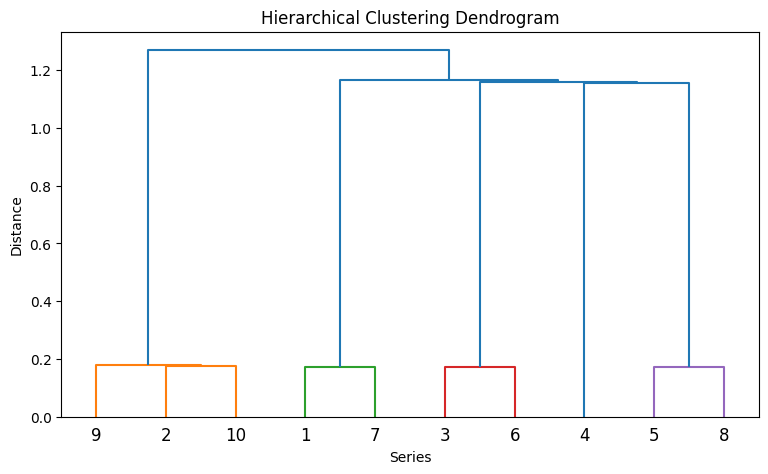

In [34]:
plt.figure(figsize=(9, 5))

sch.dendrogram(
    linkage_matrix,
    labels=[
        str(label)
        for label in corr_matrix.columns
    ]
)

plt.ylabel("Distance")
plt.xlabel("Series")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()

The dendrogram provides a direct check of whether the unsupervised clustering procedure recovers the synthetic relationships embedded in the data.

---

## 13. Quasi-Diagonal Ordering

The linkage tree is expanded back into an ordering of the original assets.

In [35]:
sorted_indices = quasi_diagonalize(
    linkage_matrix
)

sorted_indices

[8, 1, 9, 0, 6, 2, 5, 3, 4, 7]

In [36]:
sorted_assets = [
    corr_matrix.columns[i]
    for i in sorted_indices
]

sorted_assets

[9, 2, 10, 1, 7, 3, 6, 4, 5, 8]

The recovered order is:

`[9, 2, 10, 1, 7, 3, 6, 4, 5, 8]`

This ordering is economically meaningful because the intentionally related series are adjacent: $(9,2,10)$, $(1,7)$, $(3,6)$, and $(5,8)$ appear as neighboring groups, while series 4 remains comparatively isolated.

---

## 14. Clustered Correlation Structure

The original correlation matrix is reordered according to the quasi-diagonal sequence.

In [40]:
clustered_corr = corr_matrix.iloc[
    sorted_indices,
    sorted_indices
    ]

clustered_corr

,9,2,10,1,7,3,6,4,5,8
9,1.000000,0.970109,0.942667,-0.001209,-0.007593,0.012437,0.016064,0.012053,-0.005945,-0.011072
2,0.970109,1.000000,0.971349,-0.003036,-0.009117,0.008572,0.012575,0.007259,-0.009423,-0.014736
10,0.942667,0.971349,1.000000,-0.009015,-0.015202,0.007698,0.010828,0.009210,-0.007626,-0.012760
1,-0.001209,-0.003036,-0.009015,1.000000,0.970062,0.010026,0.008491,-0.010693,-0.005020,-0.001343
7,-0.007593,-0.009117,-0.015202,0.970062,1.000000,0.006205,0.004159,-0.011512,-0.009347,-0.006334
3,0.012437,0.008572,0.007698,0.010026,0.006205,1.000000,0.970485,-0.000634,0.001777,0.001854
6,0.016064,0.012575,0.010828,0.008491,0.004159,0.970485,1.000000,0.000873,0.005419,0.005404
4,0.012053,0.007259,0.009210,-0.010693,-0.011512,-0.000634,0.000873,1.000000,0.005709,0.000443
5,-0.005945,-0.009423,-0.007626,-0.005020,-0.009347,0.001777,0.005419,0.005709,1.000000,0.969998
8,-0.011072,-0.014736,-0.012760,-0.001343,-0.006334,0.001854,0.005404,0.000443,0.969998,1.000000


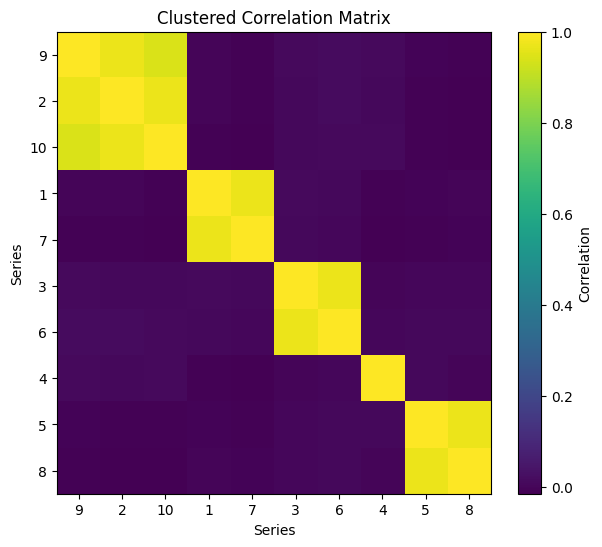

In [41]:
plt.figure(figsize=(7, 6))

plt.imshow(
    clustered_corr.values,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(clustered_corr.columns)),
    clustered_corr.columns
)

plt.yticks(
    range(len(clustered_corr.index)),
    clustered_corr.index
)

plt.xlabel("Series")
plt.ylabel("Series")
plt.title("Clustered Correlation Matrix")

plt.show()

The clustered matrix makes the hierarchical structure visually explicit: high-correlation relationships are concentrated in blocks near the diagonal. No factor rotation or change of basis is performed; only the order of the original assets changes.

This step is important for recursive bisection because contiguous segments of the ordered list now correspond approximately to coherent risk clusters.

---

## 15. HRP Portfolio Allocation

The final HRP weights are obtained by applying recursive bisection to the covariance matrix in the quasi-diagonal order.

In [46]:
hrp_weights = recursive_bisection(
    cov_matrix.values, 
    sorted_indices
)

hrp_weights.index = cov_matrix.columns[
    hrp_weights.index
]

hrp_weights = hrp_weights.sort_index()

(hrp_weights * 100).round(2)

1      7.00
2      7.59
3     10.84
4     19.03
5      9.72
6     10.19
7      6.62
8      9.10
9      7.12
10    12.79
dtype: float64

The resulting allocation is:

| Series | HRP Weight |
|---|---:|
| 1 | 7.00% |
| 2 | 7.59% |
| 3 | 10.84% |
| 4 | 19.03% |
| 5 | 9.72% |
| 6 | 10.19% |
| 7 | 6.62% |
| 8 | 9.10% |
| 9 | 7.12% |
| 10 | 12.79% |

These values reproduce the HRP column reported for the numerical example in the reference material. The five largest HRP positions sum to **62.57%**, which is also the concentration reported in the source example.

---

## 16. Inverse-Variance Portfolio Benchmark

The notebook also computes the traditional inverse-variance portfolio as a simple risk-based benchmark.

In [48]:
ivp_weights = inverse_variance_weights(
    cov_matrix.values
)

ivp_weights = pd.Series(
    ivp_weights,
    index=cov_matrix.columns,
    name="IVP"
)

(ivp_weights * 100).round(2)

1     10.36
2     10.28
3     10.36
4     10.25
5     10.31
6      9.74
7      9.80
8      9.65
9      9.64
10     9.61
Name: IVP, dtype: float64

The IVP weights are close to equal because the simulated marginal variances are similar. Unlike HRP, however, IVP uses only the diagonal of the covariance matrix and therefore does not use the correlation structure when allocating capital.

| Series | IVP Weight |
|---|---:|
| 1 | 10.36% |
| 2 | 10.28% |
| 3 | 10.36% |
| 4 | 10.25% |
| 5 | 10.31% |
| 6 | 9.74% |
| 7 | 9.80% |
| 8 | 9.65% |
| 9 | 9.64% |
| 10 | 9.61% |

The close match between these values and the reference numerical example provides an additional implementation check.

---

# Key Takeaways

- **The implementation reproduces the complete HRP construction pipeline.** Correlations are converted into distances, dependency profiles are hierarchically clustered, the tree is quasi-diagonalized, and capital is allocated through recursive bisection.
- **The method avoids covariance-matrix inversion.** This is the central robustness motivation behind HRP and distinguishes it from classical quadratic minimum-variance optimization.
- **Clustering converts statistical dependence into portfolio structure.** Related assets are placed in nearby branches, so allocation decisions occur hierarchically rather than allowing every asset to substitute freely for every other asset.
- **The synthetic experiment is successfully reproduced.** The recovered ordering `[9, 2, 10, 1, 7, 3, 6, 4, 5, 8]`, HRP weights, and IVP weights match the numerical example in the supplied reference material.
- **HRP and IVP use risk information differently.** IVP reacts only to marginal variances; HRP additionally uses the correlation structure to determine how assets are grouped and how cluster risk is propagated through the tree.

## Limitations and Next Research Steps

This notebook is a focused replication of the HRP algorithm and its synthetic numerical example. It does not yet test whether the allocation is superior on unseen data.

The most important extensions would be:

1. reproduce the paper's out-of-sample Monte Carlo comparison among HRP, IVP, and CLA;
2. test the methodology on real multi-asset return data;
3. evaluate turnover, transaction costs, and weight stability across rebalancing dates;
4. study sensitivity to linkage criteria and alternative correlation or distance estimators;
5. investigate robust covariance estimation, such as shrinkage, before hierarchical allocation.

These extensions would move the project from **algorithmic replication** toward a broader empirical study of portfolio robustness.

## Reference

The supplied source is Marcos López de Prado's **Chapter 16, “Machine Learning Asset Allocation,”** from *Advances in Financial Machine Learning*. The chapter states that a shorter version of the HRP work appeared in *The Journal of Portfolio Management*, Vol. 42, No. 4, Summer 2016, pp. 59–69.